# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
df = pd.read_csv('/content/drive/MyDrive/Skripsi/Social Anxiety Dataset.csv', sep=';')
df.columns = df.columns.str.strip()
print(f"Jumlah baris dan kolom: {df.shape}")
df.head()

Jumlah baris dan kolom: (11000, 19)


,Age,Gender,Occupation,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Smoking,Family History of Anxiety,Stress Level (1-10),Heart Rate (bpm),Breathing Rate (breaths/min),Sweating Level (1-5),Dizziness,Medication,Therapy Sessions (per month),Recent Major Life Event,Diet Quality (1-10),Anxiety Level (1-10)
0,58,Male,Nurse,6.02,1.03,192,16,No,Yes,1,117,21,1,No,Yes,9,No,1,3.0
1,39,Female,Engineer,8.06,3.08,367,15,No,No,10,113,14,3,Yes,Yes,6,Yes,3,4.0
2,42,Female,Doctor,6.06,0.05,132,1,No,No,10,79,20,1,Yes,No,1,No,6,6.0
3,43,Female,Athlete,7.00,1.06,361,15,No,No,4,69,25,2,Yes,No,5,Yes,10,2.0
4,55,Other,Athlete,7.06,2.08,531,0,No,No,3,65,12,4,No,No,6,Yes,4,4.0


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11000 entries, 0 to 10999
Data columns (total 19 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                11000 non-null  int64  
 1   Gender                             11000 non-null  object 
 2   Occupation                         11000 non-null  object 
 3   Sleep Hours                        11000 non-null  float64
 4   Physical Activity (hrs/week)       11000 non-null  float64
 5   Caffeine Intake (mg/day)           11000 non-null  int64  
 6   Alcohol Consumption (drinks/week)  11000 non-null  int64  
 7   Smoking                            11000 non-null  object 
 8   Family History of Anxiety          11000 non-null  object 
 9   Stress Level (1-10)                11000 non-null  int64  
 10  Heart Rate (bpm)                   11000 non-null  int64  
 11  Breathing Rate (breaths/min)       11000 non-null  int

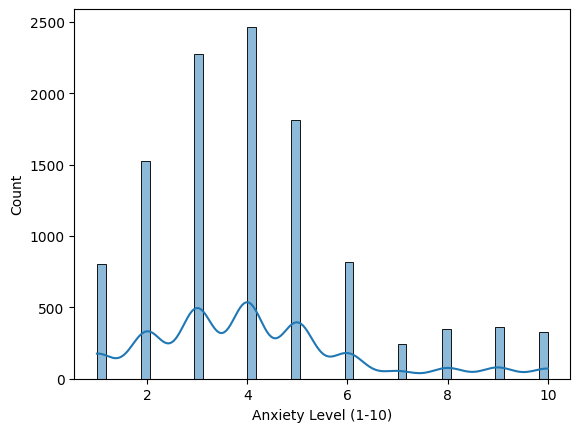

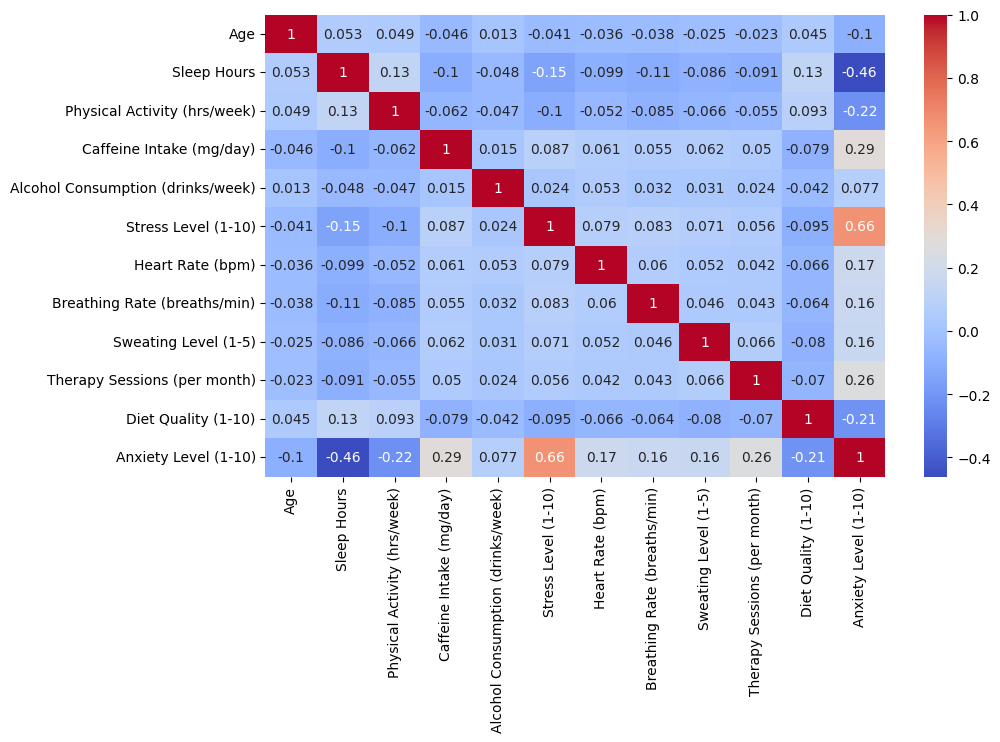

In [7]:
# Struktur data
df.info()

# Statistik deskriptif
df.describe()

# Missing values
df.isnull().sum()

# Distribusi target
sns.histplot(df['Anxiety Level (1-10)'], kde=True)
plt.show()

# Korelasi
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11000 entries, 0 to 10999
Data columns (total 19 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                11000 non-null  int64  
 1   Gender                             11000 non-null  object 
 2   Occupation                         11000 non-null  object 
 3   Sleep Hours                        11000 non-null  float64
 4   Physical Activity (hrs/week)       11000 non-null  float64
 5   Caffeine Intake (mg/day)           11000 non-null  int64  
 6   Alcohol Consumption (drinks/week)  11000 non-null  int64  
 7   Smoking                            11000 non-null  object 
 8   Family History of Anxiety          11000 non-null  object 
 9   Stress Level (1-10)                11000 non-null  int64  
 10  Heart Rate (bpm)                   11000 non-null  int64  
 11  Breathing Rate (breaths/min)       11000 non-null  int

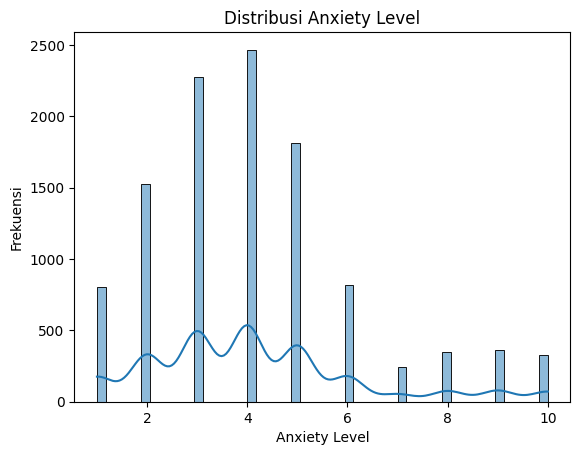

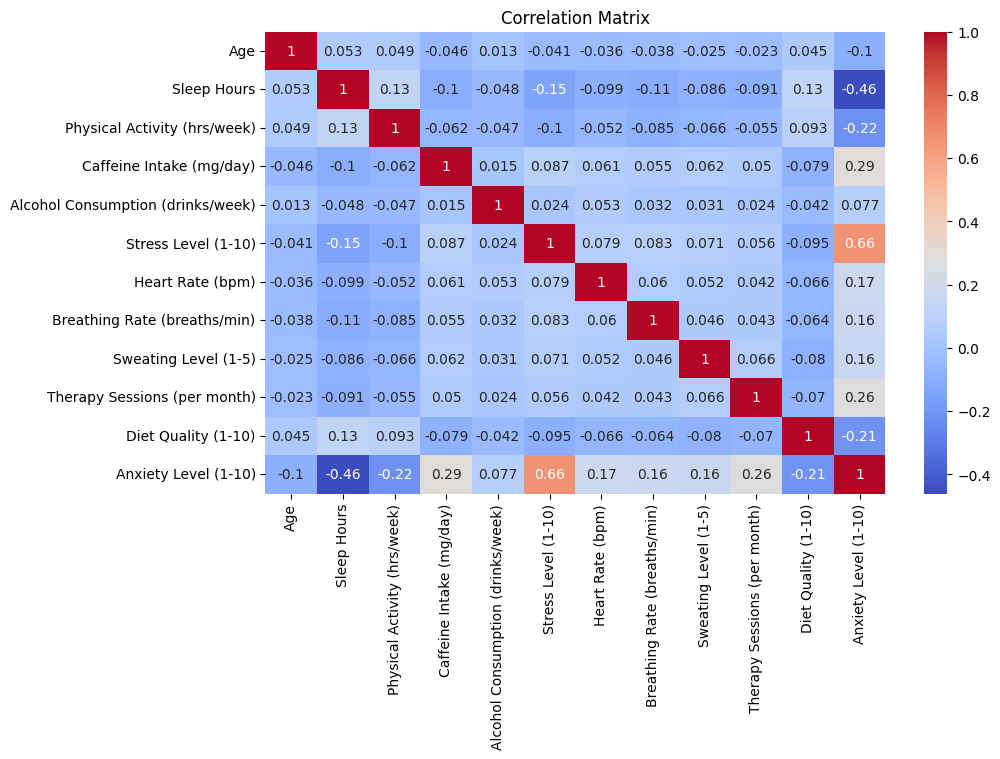

In [9]:
df.info()
df.describe()
df.isnull().sum()
sns.histplot(df['Anxiety Level (1-10)'], kde=True)
plt.title('Distribusi Anxiety Level')
plt.xlabel('Anxiety Level')
plt.ylabel('Frekuensi')
plt.show()

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [12]:
# Menghapus missing values
df = df.dropna()

# Menghapus data duplikat
df = df.drop_duplicates()

# Encoding data kategorikal
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = [
    'Gender',
    'Occupation',
    'Smoking',
    'Family History of Anxiety',
    'Dizziness',
    'Medication',
    'Recent Major Life Event'
]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))


# Transform target menjadi kategori
def categorize_anxiety(x):
    if x <= 3:
        return 0
    elif x <= 7:
        return 1
    else:
        return 2

df['Anxiety Category'] = df['Anxiety Level (1-10)'].apply(categorize_anxiety)


# Split data
from sklearn.model_selection import train_test_split

X = df.drop(['Anxiety Level (1-10)', 'Anxiety Category'], axis=1)
y = df['Anxiety Category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Preprocessing selesai")
print("Shape data:", df.shape)
print("Shape X_train:", X_train.shape)
print("Shape X_test:", X_test.shape)

print("\nDistribusi target:")
print(df['Anxiety Category'].value_counts())

df.head()

Preprocessing selesai
Shape data: (11000, 20)
Shape X_train: (8800, 18)
Shape X_test: (2200, 18)

Distribusi target:
Anxiety Category
1    5350
0    4608
2    1042
Name: count, dtype: int64


,Age,Gender,Occupation,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Smoking,Family History of Anxiety,Stress Level (1-10),Heart Rate (bpm),Breathing Rate (breaths/min),Sweating Level (1-5),Dizziness,Medication,Therapy Sessions (per month),Recent Major Life Event,Diet Quality (1-10),Anxiety Level (1-10),Anxiety Category
0,58,1,3,6.02,1.03,192,16,0,1,1,117,21,1,0,1,9,0,1,3.0,0
1,39,0,10,8.06,3.08,367,15,0,0,10,113,14,3,1,1,6,1,3,4.0,1
2,42,0,9,6.06,0.05,132,1,0,0,10,79,20,1,1,0,1,0,6,6.0,1
3,43,0,1,7.00,1.06,361,15,0,0,4,69,25,2,1,0,5,1,10,2.0,0
4,55,2,1,7.06,2.08,531,0,0,0,3,65,12,4,0,0,6,1,4,4.0,1


## Hasil Data Preprocessing

Setelah dilakukan preprocessing, dataset memiliki 11.000 data dengan total 20 kolom, termasuk kolom target baru yaitu *Anxiety Category*.

Dataset kemudian dibagi menjadi data latih (80%) dan data uji (20%), dengan masing-masing 8.800 dan 2.200 data.

Distribusi target menunjukkan bahwa:
- Kategori sedang (1) mendominasi
- Kategori rendah (0) cukup seimbang
- Kategori tinggi (2) memiliki jumlah paling sedikit

Hal ini menunjukkan bahwa dataset memiliki ketidakseimbangan kelas (class imbalance), yang dapat memengaruhi performa model dalam memprediksi kategori dengan jumlah data yang lebih kecil.